# Jittering Augmentation — Configurable N Rounds
**Multimodal Fall Detection — QUIDA Dataset (Fall-only)**

### Sample growth per round
| Rounds | Total samples | Growth |
|--------|--------------|--------|
| 0 (real) | 99 | baseline |
| 1 | 198 | 2× |
| 2 | 396 | 4× |
| 3 | 792 | 8× |
| 4 | 1,584 | 16× |
| 5 | 3,168 | 32× |

Set `N_ROUNDS` in Section 4 to any value.

### Evaluation framework (fall-only, publication-grade)
1. **One-Class SVM LOO** — boundary adherence + score gap
2. **Intra-class variance increase %** — diversity gain
3. **Nearest-neighbour (NN) diversity ratio** — fidelity vs diversity
4. **Maximum Mean Discrepancy (MMD, RBF kernel)** — distributional shift
5. **Correlation preservation** — sensor-channel relationship fidelity
6. **PCA visualisation** — reproducible 2-D projection (replaces t-SNE)

All metrics evaluated **per round separately**, not only for Round 1.


## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel

print("NumPy:  ", np.__version__)
print("Pandas: ", pd.__version__)


NumPy:   2.4.6
Pandas:  3.0.3


## 2. Load Data

In [2]:
X_imu       = np.load('X_imu_raw.npy')
X_imu_ir    = np.load('X_imu_ir_raw.npy')
X_imu_rd    = np.load('X_imu_radar_raw.npy')
X_imu_ir_rd = np.load('X_imu_ir_radar_raw.npy')
meta        = pd.read_csv('metadata.csv')

print("Tensor shapes:")
print(f"  X_imu:          {X_imu.shape}")
print(f"  X_imu_ir:       {X_imu_ir.shape}")
print(f"  X_imu_radar:    {X_imu_rd.shape}")
print(f"  X_imu_ir_radar: {X_imu_ir_rd.shape}")
print(f"  metadata:       {meta.shape}")

print()
print("Metadata columns:", list(meta.columns))
print(meta.head())

Tensor shapes:
  X_imu:          (99, 32, 3)
  X_imu_ir:       (99, 32, 771)
  X_imu_radar:    (99, 32, 1137)
  X_imu_ir_radar: (99, 32, 1905)
  metadata:       (99, 3)

Metadata columns: ['fall_id', 'subject_id', 'fall_number']
   fall_id  subject_id  fall_number
0        1           1            1
1        2           1            2
2        3           1            3
3        4           1            4
4        5           1            5


In [3]:
assert len(meta) == X_imu.shape[0], "Metadata / tensor mismatch"
assert X_imu.shape[0] == X_imu_ir.shape[0] == X_imu_rd.shape[0] == X_imu_ir_rd.shape[0]
N = X_imu.shape[0]
print(f"All checks passed. N = {N} real fall samples.")


All checks passed. N = 99 real fall samples.


## 3. Jittering Function

In [4]:
def jitter_channelwise(x: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    """
    Channel-wise scaled Gaussian jitter.
    Noise magnitude = sigma × std(channel), computed from x itself.
    Shape: (N, T, F) → (N, T, F)
    """
    rng = np.random.default_rng(seed)
    channel_std = np.std(x, axis=(0, 1), keepdims=True)   # (1, 1, F)
    noise = rng.normal(0.0, 1.0, size=x.shape)
    return x + noise * sigma * channel_std

print("jitter_channelwise() ready.")


jitter_channelwise() ready.


## 4. Configurable Cascade Jittering

**Change `N_ROUNDS` to any integer (1–5 recommended).**

The sigma schedule decays slightly each round to prevent compounding drift:
- Round 1: sigma = SIGMA_BASE
- Round 2+: sigma = SIGMA_BASE × SIGMA_DECAY^(round-1)


In [5]:
# ╔══════════════════════════════════════════════════╗
# ║           CONFIGURE HERE                        ║
# ╠══════════════════════════════════════════════════╣
N_ROUNDS    = 3       # ← change this: 1, 2, 3, 4, or 5
SIGMA_BASE  = 0.05    # noise level for round 1 (5% of channel std)
SIGMA_DECAY = 0.80    # multiply sigma by this each round
# ╚══════════════════════════════════════════════════╝

# Expected sample counts
print("Expected sample counts per round:")
total = N
for r in range(1, N_ROUNDS + 1):
    sigma_r = SIGMA_BASE * (SIGMA_DECAY ** (r - 1))
    total *= 2
    print(f"  After Round {r} (sigma={sigma_r:.4f}): {total} samples  ({total//N}× original)")
print()

# ── Run cascade ────────────────────────────────────────────────────────────────
pool_imu       = X_imu.copy()
pool_imu_ir    = X_imu_ir.copy()
pool_imu_rd    = X_imu_rd.copy()
pool_imu_ir_rd = X_imu_ir_rd.copy()

synth_batches_imu       = []
synth_batches_imu_ir    = []
synth_batches_imu_ir_rd = []
synth_batches_imu_rd    = []
meta_batches            = []

wasserstein_results = {'IMU': [], 'IMU+IR': [], 'IMU+Radar': [], 'IMU+IR+Radar': []}

for r in range(1, N_ROUNDS + 1):
    sigma_r = SIGMA_BASE * (SIGMA_DECAY ** (r - 1))
    seed_r  = 100 * r + 1

    print(f"Round {r} | input pool size = {pool_imu.shape[0]} | sigma = {sigma_r:.4f}")

    synth_imu       = jitter_channelwise(pool_imu,       sigma=sigma_r, seed=seed_r)
    synth_imu_ir    = jitter_channelwise(pool_imu_ir,    sigma=sigma_r, seed=seed_r)
    synth_imu_rd    = jitter_channelwise(pool_imu_rd,    sigma=sigma_r, seed=seed_r)
    synth_imu_ir_rd = jitter_channelwise(pool_imu_ir_rd, sigma=sigma_r, seed=seed_r)

    # ------------------------------------------------------------------
    # Wasserstein Distance
    #
    # We report TWO complementary metrics:
    #
    #   1. Current Round Drift
    #      Original data vs newly generated batch.
    #
    #   2. Accumulated Drift
    #      Original data vs the entire augmented pool after this round.
    #
    # Current-round drift evaluates the quality of newly generated samples,
    # whereas accumulated drift measures how much the dataset changes after
    # repeated augmentation.
    # ------------------------------------------------------------------

    for tag, real_orig, synth_batch, accumulated_pool in [

        ('IMU',
         X_imu,
         synth_imu,
         np.concatenate([pool_imu, synth_imu], axis=0)),

        ('IMU+IR',
         X_imu_ir,
         synth_imu_ir,
         np.concatenate([pool_imu_ir, synth_imu_ir], axis=0)),

        ('IMU+Radar',
         X_imu_rd,
         synth_imu_rd,
         np.concatenate([pool_imu_rd, synth_imu_rd], axis=0)),

        ('IMU+IR+Radar',
         X_imu_ir_rd,
         synth_imu_ir_rd,
         np.concatenate([pool_imu_ir_rd, synth_imu_ir_rd], axis=0)),

    ]:

        # Current-round drift
        current_dists = [
            wasserstein_distance(
                real_orig[:, :, f].flatten(),
                synth_batch[:, :, f].flatten()
            )
            for f in range(real_orig.shape[2])
        ]

        # Accumulated drift
        accumulated_dists = [
            wasserstein_distance(
                real_orig[:, :, f].flatten(),
                accumulated_pool[:, :, f].flatten()
            )
            for f in range(real_orig.shape[2])
        ]

        wasserstein_results[tag].append({
            "current": np.mean(current_dists),
            "accumulated": np.mean(accumulated_dists)
        })

    # ── Metadata bookkeeping (once per round, not once per tag) ───────────
    m = pd.concat([meta] * (pool_imu.shape[0] // N) + (
        [meta.iloc[:pool_imu.shape[0] % N]] if pool_imu.shape[0] % N else []
    ), ignore_index=True)
    m['is_augmented'] = r
    m['source']       = f'jitter_r{r}'
    meta_batches.append(m)

    # ── Pool updates (once per round, not once per tag) ────────────────────
    pool_imu       = np.concatenate([pool_imu,       synth_imu],       axis=0)
    pool_imu_ir    = np.concatenate([pool_imu_ir,    synth_imu_ir],    axis=0)
    pool_imu_rd    = np.concatenate([pool_imu_rd,    synth_imu_rd],    axis=0)
    pool_imu_ir_rd = np.concatenate([pool_imu_ir_rd, synth_imu_ir_rd], axis=0)

    synth_batches_imu.append(synth_imu)
    synth_batches_imu_ir.append(synth_imu_ir)
    synth_batches_imu_ir_rd.append(synth_imu_ir_rd)
    synth_batches_imu_rd.append(synth_imu_rd)

X_imu_aug       = pool_imu
X_imu_ir_aug    = pool_imu_ir
X_imu_ir_rd_aug = pool_imu_ir_rd
X_imu_rd_aug    = pool_imu_rd

print(f"\n{'='*50}")
print(f"FINAL AUGMENTED SHAPES")
print(f"{'='*50}")
print(f"  X_imu_aug:          {X_imu_aug.shape}")
print(f"  X_imu_ir_aug:       {X_imu_ir_aug.shape}")
print(f"  X_imu_rd_aug:    {X_imu_rd_aug.shape}")
print(f"  X_imu_ir_rd_aug:    {X_imu_ir_rd_aug.shape}")

Expected sample counts per round:
  After Round 1 (sigma=0.0500): 198 samples  (2× original)
  After Round 2 (sigma=0.0400): 396 samples  (4× original)
  After Round 3 (sigma=0.0320): 792 samples  (8× original)

Round 1 | input pool size = 99 | sigma = 0.0500
Round 2 | input pool size = 198 | sigma = 0.0400
Round 3 | input pool size = 396 | sigma = 0.0320

FINAL AUGMENTED SHAPES
  X_imu_aug:          (792, 32, 3)
  X_imu_ir_aug:       (792, 32, 771)
  X_imu_rd_aug:    (792, 32, 1137)
  X_imu_ir_rd_aug:    (792, 32, 1905)


## 5. Build Augmented Metadata

---



In [6]:
meta_real = meta.copy()

meta_real['is_augmented'] = 0
meta_real['source'] = 'real'


# Keep only current experiment rounds
meta_batches_current = meta_batches[:N_ROUNDS]


meta_aug = pd.concat(
    [meta_real] + meta_batches_current,
    ignore_index=True
)


print(f"Metadata shape: {meta_aug.shape}")
print()

print(
    meta_aug['source']
    .value_counts()
    .sort_index()
)

print()

print(f"Total real:      {(meta_aug['source']=='real').sum()}")
print(f"Total synthetic: {(meta_aug['source']!='real').sum()}")
print(f"Grand total:     {len(meta_aug)}")


# Integrity check
expected_total = N + sum(
    len(batch) for batch in synth_batches_imu[:N_ROUNDS]
)

print()
print(f"Expected total samples: {expected_total}")

if len(meta_aug) == expected_total:
    print("✓ Metadata matches augmented dataset size")
else:
    print("✗ Metadata size mismatch detected")

Metadata shape: (792, 5)

source
jitter_r1     99
jitter_r2    198
jitter_r3    396
real          99
Name: count, dtype: int64

Total real:      99
Total synthetic: 693
Grand total:     792

Expected total samples: 792
✓ Metadata matches augmented dataset size


## 6. Wasserstein Drift Curve

Mean Wasserstein distance between original real samples and synthetic samples per round.
- Flat / slow growth → safe to add more rounds
- Sharp jump → that round is introducing too much drift


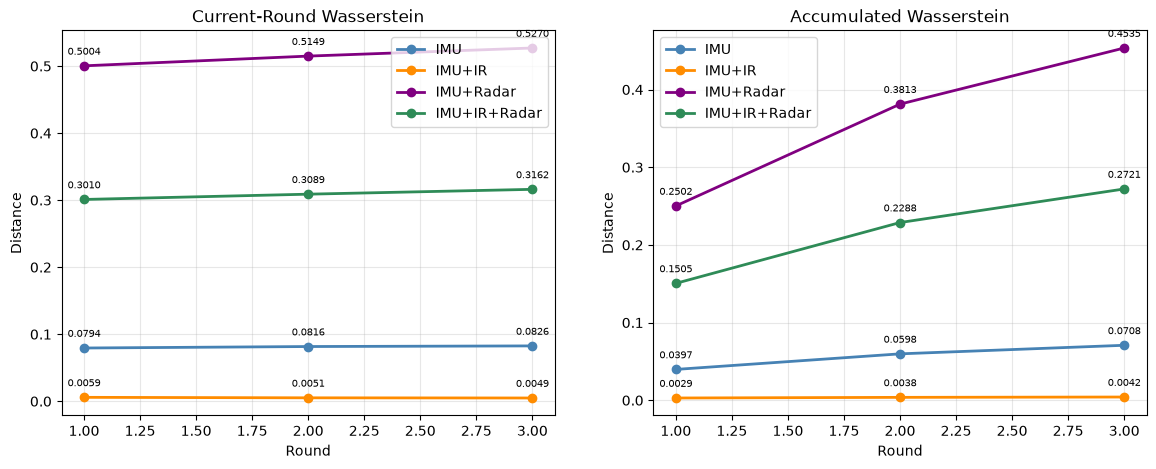


Current-round Wasserstein:

IMU
 Round 1: 0.079444
 Round 2: 0.081642 (1.028× prev)
 Round 3: 0.082581 (1.012× prev)

IMU+IR
 Round 1: 0.005854
 Round 2: 0.005130 (0.876× prev)
 Round 3: 0.004867 (0.949× prev)

IMU+Radar
 Round 1: 0.500404
 Round 2: 0.514923 (1.029× prev)
 Round 3: 0.527006 (1.023× prev)

IMU+IR+Radar
 Round 1: 0.301048
 Round 2: 0.308930 (1.026× prev)
 Round 3: 0.316152 (1.023× prev)

Accumulated Wasserstein:

IMU
 Round 1: 0.039722
 Round 2: 1.505× prev
 Round 3: 1.185× prev

IMU+IR
 Round 1: 0.002927
 Round 2: 1.282× prev
 Round 3: 1.114× prev

IMU+Radar
 Round 1: 0.250202
 Round 2: 1.524× prev
 Round 3: 1.190× prev

IMU+IR+Radar
 Round 1: 0.150524
 Round 2: 1.520× prev
 Round 3: 1.189× prev


In [11]:
rounds_x = np.arange(1, N_ROUNDS + 1)

colors = {
    'IMU': 'steelblue',
    'IMU+IR': 'darkorange',
    'IMU+Radar': 'purple',
    'IMU+IR+Radar': 'seagreen'
}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --------------------------------------------------
# Current-round drift
# --------------------------------------------------

for tag, vals in wasserstein_results.items():

    y = [v["current"] for v in vals]

    axes[0].plot(
        rounds_x,
        y,
        marker='o',
        linewidth=2,
        color=colors[tag],
        label=tag
    )

    for i, v in enumerate(y):
        axes[0].annotate(
            f"{v:.4f}",
            (rounds_x[i], v),
            textcoords="offset points",
            xytext=(0,8),
            ha="center",
            fontsize=7
        )

axes[0].set_title("Current-Round Wasserstein")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Distance")
axes[0].grid(alpha=0.3)
axes[0].legend()


# --------------------------------------------------
# Accumulated drift
# --------------------------------------------------

for tag, vals in wasserstein_results.items():

    y = [v["accumulated"] for v in vals]

    axes[1].plot(
        rounds_x,
        y,
        marker='o',
        linewidth=2,
        color=colors[tag],
        label=tag
    )

    for i, v in enumerate(y):
        axes[1].annotate(
            f"{v:.4f}",
            (rounds_x[i], v),
            textcoords="offset points",
            xytext=(0,8),
            ha="center",
            fontsize=7
        )

axes[1].set_title("Accumulated Wasserstein")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Distance")
axes[1].grid(alpha=0.3)
axes[1].legend()

OUTPUT_DIR = "imgs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.savefig(
    os.path.join(OUTPUT_DIR, "wasserstein_drift_curve.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nCurrent-round Wasserstein:")
for tag, vals in wasserstein_results.items():

    print(f"\n{tag}")

    prev = None

    for r, v in enumerate(vals,1):

        cur = v["current"]

        if prev is None:
            print(f" Round {r}: {cur:.6f}")
        else:
            print(
                f" Round {r}: {cur:.6f} ({cur/prev:.3f}× prev)"
            )

        prev = cur


print("\nAccumulated Wasserstein:")

for tag, vals in wasserstein_results.items():

    print(f"\n{tag}")

    prev = None

    for r, v in enumerate(vals,1):

        cur = v["accumulated"]

        if prev is None:
            print(f" Round {r}: {cur:.6f}")
        else:
            print(
                f" Round {r}: {cur/prev:.3f}× prev"
            )

        prev = cur

## 7. Data Integrity Check

In [12]:
## 7. Data Integrity Check

for name, arr in [
    ("X_imu_aug",       X_imu_aug),
    ("X_imu_ir_aug",    X_imu_ir_aug),
    ("X_imu_rd_aug",    X_imu_rd_aug),
    ("X_imu_ir_rd_aug", X_imu_ir_rd_aug),
]:

    nans = np.isnan(arr).sum()
    infs = np.isinf(arr).sum()

    ok = "✓ clean" if nans + infs == 0 else f"✗ NaNs={nans} Infs={infs}"

    print(f"  {name:28s} shape={arr.shape}  {ok}")


print()

print("Global stats comparison (real vs full augmented pool — IMU):")

for name, arr in [
    ("Real ", X_imu),
    ("Aug  ", X_imu_aug)
]:

    print(
        f"  {name}| mean={np.mean(arr):+.4f}  "
        f"std={np.std(arr):.4f}  "
        f"min={np.min(arr):+.4f}  "
        f"max={np.max(arr):+.4f}"
    )


print(
    f"  Δmean={abs(np.mean(X_imu_aug)-np.mean(X_imu)):.6f}  "
    f"Δstd={abs(np.std(X_imu_aug)-np.std(X_imu)):.6f}"
)


print()

print("Shape consistency:")

for name, arr in [
    ("X_imu_aug", X_imu_aug),
    ("X_imu_ir_aug", X_imu_ir_aug),
    ("X_imu_rd_aug", X_imu_rd_aug),
    ("X_imu_ir_rd_aug", X_imu_ir_rd_aug),
]:

    print(f"  ✓ {name}: {arr.shape[0]} samples")

  X_imu_aug                    shape=(792, 32, 3)  ✓ clean
  X_imu_ir_aug                 shape=(792, 32, 771)  ✓ clean
  X_imu_rd_aug                 shape=(792, 32, 1137)  ✓ clean
  X_imu_ir_rd_aug              shape=(792, 32, 1905)  ✓ clean

Global stats comparison (real vs full augmented pool — IMU):
  Real | mean=+1.7345  std=6.3463  min=-73.3806  max=+72.0936
  Aug  | mean=+1.7345  std=6.3550  min=-73.8939  max=+72.3617
  Δmean=0.000079  Δstd=0.008706

Shape consistency:
  ✓ X_imu_aug: 792 samples
  ✓ X_imu_ir_aug: 792 samples
  ✓ X_imu_rd_aug: 792 samples
  ✓ X_imu_ir_rd_aug: 792 samples


## 8. IMU Distribution Plots — All Rounds

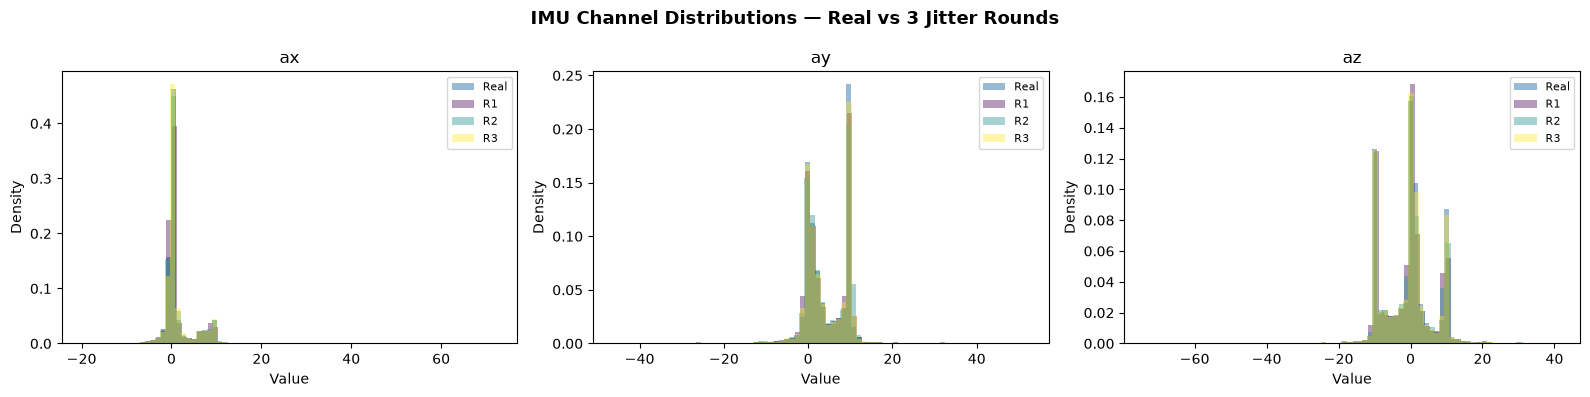

Saved: imgs\jitter_distributions_all_rounds.png


In [16]:
round_colors = plt.cm.viridis(np.linspace(0, 1, N_ROUNDS))
channel_names = ['ax', 'ay', 'az']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    f'IMU Channel Distributions — Real vs {N_ROUNDS} Jitter Rounds',
    fontsize=13,
    fontweight='bold'
)

for i, (ax, ch) in enumerate(zip(axes, channel_names)):
    ax.hist(
        X_imu[:, :, i].flatten(),
        bins=80,
        alpha=0.55,
        label='Real',
        color='steelblue',
        density=True
    )

    for r_i, synth_batch in enumerate(synth_batches_imu):
        color = round_colors[min(r_i, len(round_colors) - 1)]
        ax.hist(
            synth_batch[:N, :, i].flatten(),
            bins=80,
            alpha=0.40,
            label=f'R{r_i + 1}',
            color=color,
            density=True
        )

    ax.set_title(ch)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "jitter_distributions_all_rounds.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {os.path.join(OUTPUT_DIR, 'jitter_distributions_all_rounds.png')}")

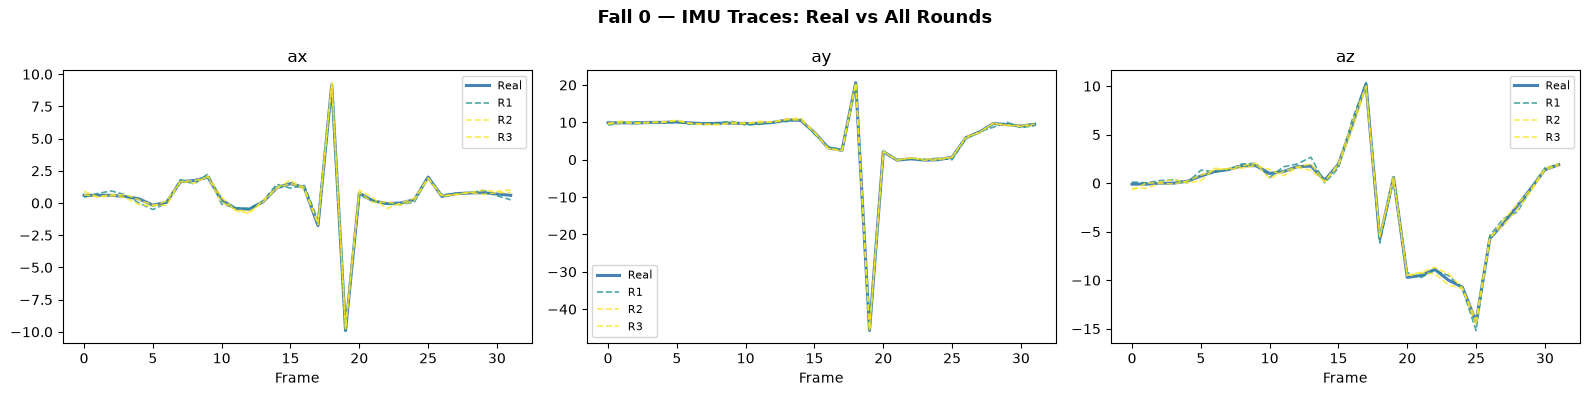

Saved: jitter_traces_all_rounds.png


In [18]:
FALL_IDX = 0
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Fall {FALL_IDX} — IMU Traces: Real vs All Rounds',
             fontsize=13, fontweight='bold')

for i, (ax, ch) in enumerate(zip(axes, channel_names)):
    ax.plot(X_imu[FALL_IDX, :, i], label='Real', color='steelblue', linewidth=2.2)
    for r_i, synth_batch in enumerate(synth_batches_imu):
        color = round_colors[min(r_i + 1, len(round_colors) - 1)]
        ax.plot(synth_batch[FALL_IDX, :, i], label=f'R{r_i+1}',
                color=color, linewidth=1.2, linestyle='--', alpha=0.8)
    ax.set_title(ch)
    ax.set_xlabel('Frame')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "jitter_traces_all_rounds.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()
print("Saved: jitter_traces_all_rounds.png")


## 9. Evaluation Metric Functions

Five complementary metrics evaluated per round independently.


In [19]:
def get_pca_projection(X_real_flat, X_synth_flat, n_components=30):
    """
    Fit PCA on real samples only, then project real and synthetic samples.
    Returns scaled arrays ready for distance-based metrics.
    """

    n_comp = min(
        n_components,
        X_real_flat.shape[1],
        X_real_flat.shape[0] - 2
    )

    pca = PCA(
        n_components=n_comp,
        random_state=42
    )

    scaler = StandardScaler()

    X_real_pca = pca.fit_transform(X_real_flat)
    X_real_sc = scaler.fit_transform(X_real_pca)

    X_synth_pca = pca.transform(X_synth_flat)
    X_synth_sc = scaler.transform(X_synth_pca)

    return X_real_sc, X_synth_sc, pca, scaler



# ── METRIC 1: OCSVM Leave-One-Out ─────────────────────────────────────────────
def compute_ocsvm_loo(X_real_sc, X_synth_sc):
    """
    Leave-one-out One-Class SVM.

    Synthetic samples are evaluated using the same number of samples
    as real data (paired comparison).
    """

    N = X_real_sc.shape[0]

    real_scores = []
    synth_scores = []

    for i in range(N):

        train_idx = np.delete(
            np.arange(N),
            i
        )

        clf = OneClassSVM(
            kernel='rbf',
            nu=0.1,
            gamma='scale'
        )

        clf.fit(
            X_real_sc[train_idx]
        )

        real_scores.append(
            clf.decision_function(
                X_real_sc[[i]]
            )[0]
        )

        synth_scores.append(
            clf.decision_function(
                X_synth_sc[[i]]
            )[0]
        )


    real_scores = np.array(real_scores)
    synth_scores = np.array(synth_scores)


    return {
        'real_boundary_pct':
            100 * (real_scores >= 0).sum() / N,

        'synth_boundary_pct':
            100 * (synth_scores >= 0).sum() / N,

        'mean_score_real':
            real_scores.mean(),

        'mean_score_synth':
            synth_scores.mean(),

        'score_gap':
            abs(
                real_scores.mean()
                -
                synth_scores.mean()
            ),

        'real_scores':
            real_scores,

        'synth_scores':
            synth_scores
    }



# ── METRIC 2: Variance Increase ───────────────────────────────────────────────
def compute_variance_increase(X_real, X_aug_pool):
    """
    Compare average feature variance between real and augmented datasets.

    X_real:
        (N, T, F)

    X_aug_pool:
        (N_aug, T, F)
    """

    X_real_flat = X_real.reshape(
        X_real.shape[0],
        -1
    )

    X_aug_flat = X_aug_pool.reshape(
        X_aug_pool.shape[0],
        -1
    )


    var_real = np.var(
        X_real_flat,
        axis=0
    ).mean()


    var_aug = np.var(
        X_aug_flat,
        axis=0
    ).mean()


    return {

        'var_real':
            var_real,

        'var_aug':
            var_aug,

        'variance_inc_%':
            ((var_aug - var_real) / var_real) * 100
    }



# ── METRIC 3: Nearest Neighbour Diversity Ratio ───────────────────────────────
def compute_nn_diversity(X_real_sc, X_synth_sc):
    """
    Compare synthetic-real nearest neighbour distance
    against real-real nearest neighbour distance.

    Ratio:
        ~1     good balance
        >1.5   possible drift
        >2     strong drift
    """

    from sklearn.metrics.pairwise import euclidean_distances


    # Real-real distances
    D_rr = euclidean_distances(
        X_real_sc,
        X_real_sc
    )

    np.fill_diagonal(
        D_rr,
        np.inf
    )


    real_nn_dist = D_rr.min(
        axis=1
    ).mean()


    # Synthetic-real distances
    D_sr = euclidean_distances(
        X_synth_sc,
        X_real_sc
    )

    synth_nn_dist = D_sr.min(
        axis=1
    ).mean()


    nn_ratio = (
        synth_nn_dist / real_nn_dist
        if real_nn_dist > 0
        else np.nan
    )


    return {

        'real_nn_dist':
            real_nn_dist,

        'synth_nn_dist':
            synth_nn_dist,

        'nn_ratio':
            nn_ratio
    }



# ── METRIC 4: Maximum Mean Discrepancy ────────────────────────────────────────
def compute_mmd(X_real_sc, X_synth_sc, gamma=1.0):
    """
    RBF kernel Maximum Mean Discrepancy.

    Lower values indicate closer distributions.
    """

    MAX_SAMPLES = 200

    rng = np.random.default_rng(0)


    idx_r = rng.choice(
        len(X_real_sc),
        min(MAX_SAMPLES, len(X_real_sc)),
        replace=False
    )

    idx_s = rng.choice(
        len(X_synth_sc),
        min(MAX_SAMPLES, len(X_synth_sc)),
        replace=False
    )


    Xr = X_real_sc[idx_r]
    Xs = X_synth_sc[idx_s]


    K_rr = rbf_kernel(
        Xr,
        Xr,
        gamma=gamma
    )

    K_ss = rbf_kernel(
        Xs,
        Xs,
        gamma=gamma
    )

    K_rs = rbf_kernel(
        Xr,
        Xs,
        gamma=gamma
    )


    mmd2 = (
        K_rr.mean()
        -
        2 * K_rs.mean()
        +
        K_ss.mean()
    )


    return {
        'mmd':
            float(
                np.sqrt(
                    max(mmd2, 0.0)
                )
            )
    }



# ── METRIC 5: Correlation Preservation ────────────────────────────────────────
def compute_correlation_preservation(X_real, X_synth_round):
    """
    Compare sensor feature correlations between real and synthetic data.

    Lower correlation difference means better preservation.
    """

    MAX_FEATURES = 100


    X_r = X_real.reshape(
        X_real.shape[0],
        -1
    )

    X_s = X_synth_round.reshape(
        X_synth_round.shape[0],
        -1
    )


    n_feat = min(
        MAX_FEATURES,
        X_r.shape[1],
        X_r.shape[0] - 2,
        X_s.shape[0] - 2
    )


    scaler = StandardScaler()

    Xr_sc = scaler.fit_transform(
        X_r
    )

    Xs_sc = scaler.transform(
        X_s
    )


    pca = PCA(
        n_components=n_feat,
        random_state=42
    )


    Xr_red = pca.fit_transform(
        Xr_sc
    )

    Xs_red = pca.transform(
        Xs_sc
    )


    corr_real = np.corrcoef(
        Xr_red,
        rowvar=False
    )

    corr_synth = np.corrcoef(
        Xs_red,
        rowvar=False
    )


    return {
        'corr_diff':
            np.abs(
                corr_real - corr_synth
            ).mean()
    }



print("All evaluation metric functions defined.")
print("  compute_ocsvm_loo()")
print("  compute_variance_increase()")
print("  compute_nn_diversity()")
print("  compute_mmd()")
print("  compute_correlation_preservation()")

All evaluation metric functions defined.
  compute_ocsvm_loo()
  compute_variance_increase()
  compute_nn_diversity()
  compute_mmd()
  compute_correlation_preservation()


## 10. Per-Round Evaluation

Each augmentation round is evaluated **independently** against the original
99 real samples. This reveals whether quality changes as rounds accumulate.


In [20]:
def evaluate_all_rounds(
    X_real,
    synth_batches,
    X_aug_pools,
    wdist_list,
    exp_name,
):
    """
    Evaluate every round separately.

    Parameters
    ----------
    X_real       : (N, T, F) real samples
    synth_batches: list of length N_ROUNDS — each is the raw synthetic batch
                   produced in that round (size may exceed N; first N used)
    X_aug_pools  : list of length N_ROUNDS — cumulative pool after each round
    wdist_list   : list of mean Wasserstein distances already computed
    exp_name     : string label for printing

    Returns
    -------
    list of per-round metric dicts
    """
    print(f"\n{'#'*70}")
    print(f"  {exp_name}")
    print(f"{'#'*70}")

    N_real     = X_real.shape[0]
    X_real_flat = X_real.reshape(N_real, -1)
    results    = []

    for r_i, synth_batch in enumerate(synth_batches):
        r = r_i + 1
        print(f"\n  --- Round {r} ---")

        # Use first N_real samples from this batch
        # Match synthetic sample count with real samples for paired metrics
        n_eval = min(N_real, synth_batch.shape[0])

        X_synth = synth_batch[:n_eval]

        X_synth_flat = X_synth.reshape(n_eval, -1)
        X_real_eval = X_real[:n_eval]

        X_aug_pool    = X_aug_pools[r_i]   # cumulative pool after round r

        # PCA projection (shared for OCSVM + NN + MMD)
        X_real_eval_flat = X_real_eval.reshape(n_eval, -1)

        X_real_sc, X_synth_sc, _, _ = get_pca_projection(
            X_real_eval_flat,
            X_synth_flat,
            n_components=30
        )

        # ── OCSVM ──────────────────────────────────────────────────────────
        ocsvm = compute_ocsvm_loo(
            X_real_sc,
            X_synth_sc
        )
        print(f"    OCSVM  real={ocsvm['real_boundary_pct']:.1f}%  "              f"synth={ocsvm['synth_boundary_pct']:.1f}%  "              f"score_gap={ocsvm['score_gap']:.4f}")

        # ── Variance ────────────────────────────────────────────────────────
        var = compute_variance_increase(X_real, X_aug_pool)
        print(f"    Variance increase: {var['variance_inc_%']:+.3f}%")

        # ── NN Diversity ────────────────────────────────────────────────────
        nn = compute_nn_diversity(X_real_sc, X_synth_sc)
        nn_flag = (
            "very_close" if nn['nn_ratio'] < 0.5 else
            "good" if nn['nn_ratio'] < 1.0 else
            "healthy" if nn['nn_ratio'] < 1.5 else
            "drift"
        )
        print(f"    NN ratio: {nn['nn_ratio']:.4f}  ({nn_flag})")

        # ── MMD ─────────────────────────────────────────────────────────────
        mmd = compute_mmd(X_real_sc, X_synth_sc)
        print(f"    MMD:     {mmd['mmd']:.6f}")

        # ── Correlation preservation ─────────────────────────────────────────
        corr = compute_correlation_preservation(
            X_real_eval,
            X_synth
        )
        print(f"    Corr diff: {corr['corr_diff']:.6f}")

        row = {
            'Round':                  r,
            'Samples':                X_aug_pool.shape[0],
            'Real_boundary_%':        round(ocsvm['real_boundary_pct'], 1),
            'Synth_boundary_%':       round(ocsvm['synth_boundary_pct'], 1),
            'Score_gap':              round(ocsvm['score_gap'], 4),
            'Variance_inc_%':         round(var['variance_inc_%'], 3),
            'Wasserstein':            round(wdist_list[r_i], 6),
            'NN_ratio':               round(nn['nn_ratio'], 4),
            'MMD':                    round(mmd['mmd'], 6),
            'Corr_diff':              round(corr['corr_diff'], 6),
            '_real_scores':           ocsvm['real_scores'],
            '_synth_scores':          ocsvm['synth_scores'],
            '_X_real_sc':             X_real_sc,
            '_X_synth_sc':            X_synth_sc,
        }
        results.append(row)

    return results


print("evaluate_all_rounds() defined.")


evaluate_all_rounds() defined.


In [21]:
# Build cumulative pool list for each experiment
pools_imu       = []
pools_imu_ir    = []
pools_imu_rd = []
pools_imu_ir_rd = []

pool_tmp_imu       = X_imu.copy()
pool_tmp_imu_ir    = X_imu_ir.copy()
pool_tmp_imu_rd = X_imu_rd.copy()
pool_tmp_imu_ir_rd = X_imu_ir_rd.copy()

for r_i in range(N_ROUNDS):
    pool_tmp_imu       = np.concatenate([pool_tmp_imu,       synth_batches_imu[r_i]],       axis=0)
    pool_tmp_imu_ir    = np.concatenate([pool_tmp_imu_ir,    synth_batches_imu_ir[r_i]],    axis=0)
    pool_tmp_imu_rd = np.concatenate([pool_tmp_imu_rd, synth_batches_imu_rd[r_i]], axis=0)
    pool_tmp_imu_ir_rd = np.concatenate([pool_tmp_imu_ir_rd, synth_batches_imu_ir_rd[r_i]], axis=0)
    pools_imu.append(pool_tmp_imu.copy())
    pools_imu_ir.append(pool_tmp_imu_ir.copy())
    pools_imu_rd.append(pool_tmp_imu_rd.copy())
    pools_imu_ir_rd.append(pool_tmp_imu_ir_rd.copy())

print(f"Cumulative pool sizes per round:")
for r_i in range(N_ROUNDS):
    print(
    f"  Round {r_i+1}: "
    f"IMU={pools_imu[r_i].shape[0]}  "
    f"IMU+IR={pools_imu_ir[r_i].shape[0]}  "
    f"IMU+Radar={pools_imu_rd[r_i].shape[0]}  "
    f"IMU+IR+Radar={pools_imu_ir_rd[r_i].shape[0]}"
)


Cumulative pool sizes per round:
  Round 1: IMU=198  IMU+IR=198  IMU+Radar=198  IMU+IR+Radar=198
  Round 2: IMU=396  IMU+IR=396  IMU+Radar=396  IMU+IR+Radar=396
  Round 3: IMU=792  IMU+IR=792  IMU+Radar=792  IMU+IR+Radar=792


In [22]:
# Rename Wasserstein results for evaluation compatibility
wdist_rounds = {
    "IMU": [
        x["current"] if isinstance(x, dict) else x
        for x in wasserstein_results["IMU"]
    ],

    "IMU+IR": [
        x["current"] if isinstance(x, dict) else x
        for x in wasserstein_results["IMU+IR"]
    ],

    "IMU+Radar": [
        x["current"] if isinstance(x, dict) else x
        for x in wasserstein_results["IMU+Radar"]
    ],

    "IMU+IR+Radar": [
        x["current"] if isinstance(x, dict) else x
        for x in wasserstein_results["IMU+IR+Radar"]
    ]
}

print("wdist_rounds created:")
print(wdist_rounds.keys())

wdist_rounds created:
dict_keys(['IMU', 'IMU+IR', 'IMU+Radar', 'IMU+IR+Radar'])


In [23]:
# ── Run all experiments ───────────────────────────────────────────────────────
print("Running per-round evaluation — this may take a few minutes (OCSVM LOO)...")

results_imu = evaluate_all_rounds(
    X_imu,
    synth_batches_imu,
    pools_imu,
    wdist_rounds['IMU'],
    "Exp A — IMU only"
)


results_imu_ir = evaluate_all_rounds(
    X_imu_ir,
    synth_batches_imu_ir,
    pools_imu_ir,
    wdist_rounds['IMU+IR'],
    "Exp B — IMU + IR"
)


results_imu_rd = evaluate_all_rounds(
    X_imu_rd,
    synth_batches_imu_rd,
    pools_imu_rd,
    wdist_rounds['IMU+Radar'],
    "Exp C — IMU + Radar"
)


results_imu_ir_rd = evaluate_all_rounds(
    X_imu_ir_rd,
    synth_batches_imu_ir_rd,
    pools_imu_ir_rd,
    wdist_rounds['IMU+IR+Radar'],
    "Exp D — IMU + IR + Radar"
)


print("\nAll evaluations complete.")

Running per-round evaluation — this may take a few minutes (OCSVM LOO)...

######################################################################
  Exp A — IMU only
######################################################################

  --- Round 1 ---
    OCSVM  real=56.6%  synth=55.6%  score_gap=0.0032
    Variance increase: +0.195%
    NN ratio: 0.0729  (very_close)
    MMD:     0.047540
    Corr diff: 0.086251

  --- Round 2 ---
    OCSVM  real=56.6%  synth=55.6%  score_gap=0.0009
    Variance increase: +0.348%
    NN ratio: 0.0580  (very_close)
    MMD:     0.038464
    Corr diff: 0.079054

  --- Round 3 ---
    OCSVM  real=56.6%  synth=54.5%  score_gap=0.0014
    Variance increase: +0.395%
    NN ratio: 0.0468  (very_close)
    MMD:     0.030991
    Corr diff: 0.075526

######################################################################
  Exp B — IMU + IR
######################################################################

  --- Round 1 ---
    OCSVM  real=62.6%  synth=62

## 11. Per-Round Results Tables

In [24]:
## 11. Per-Round Results Tables

def results_to_df(results, exp_name):
    """
    Convert per-round result dictionaries to DataFrame.
    Private keys used for plotting are removed.
    """

    public_keys = [
        k for k in results[0].keys()
        if not k.startswith('_')
    ]

    rows = [
        {k: r[k] for k in public_keys}
        for r in results
    ]

    df = pd.DataFrame(rows)
    df.insert(0, 'Experiment', exp_name)

    return df



df_imu = results_to_df(
    results_imu,
    'IMU'
)

df_imu_ir = results_to_df(
    results_imu_ir,
    'IMU+IR'
)

df_imu_rd = results_to_df(
    results_imu_rd,
    'IMU+Radar'
)

df_imu_ir_rd = results_to_df(
    results_imu_ir_rd,
    'IMU+IR+Radar'
)



all_results_df = pd.concat(
    [
        df_imu,
        df_imu_ir,
        df_imu_rd,
        df_imu_ir_rd
    ],
    ignore_index=True
)



for name, df in [
    ('IMU', df_imu),
    ('IMU+IR', df_imu_ir),
    ('IMU+Radar', df_imu_rd),
    ('IMU+IR+Radar', df_imu_ir_rd)
]:

    print(f"\n{'='*75}")
    print(f"  {name} — Per-Round Results")
    print(f"{'='*75}")
    print(df.to_string(index=False))


print("\nCombined results table:")
print(all_results_df.to_string(index=False))


  IMU — Per-Round Results
Experiment  Round  Samples  Real_boundary_%  Synth_boundary_%  Score_gap  Variance_inc_%  Wasserstein  NN_ratio      MMD  Corr_diff
       IMU      1      198             56.6              55.6     0.0032           0.195     0.079444    0.0729 0.047540   0.086251
       IMU      2      396             56.6              55.6     0.0009           0.348     0.081642    0.0580 0.038464   0.079054
       IMU      3      792             56.6              54.5     0.0014           0.395     0.082581    0.0468 0.030991   0.075526

  IMU+IR — Per-Round Results
Experiment  Round  Samples  Real_boundary_%  Synth_boundary_%  Score_gap  Variance_inc_%  Wasserstein  NN_ratio      MMD  Corr_diff
    IMU+IR      1      198             62.6              62.6     0.0006           0.160     0.005854    0.0139 0.009698   0.000996
    IMU+IR      2      396             62.6              62.6     0.0001           0.250     0.005130    0.0110 0.007735   0.000790
    IMU+IR      3  

In [27]:
# Folder for CSV evaluation tables
TABLE_DIR = "tables"
os.makedirs(TABLE_DIR, exist_ok=True)

# --------------------------------------------------
# Save individual per-experiment round tables
# --------------------------------------------------

df_imu.to_csv(
    os.path.join(TABLE_DIR, "eval_rounds_imu.csv"),
    index=False
)

df_imu_ir.to_csv(
    os.path.join(TABLE_DIR, "eval_rounds_imu_ir.csv"),
    index=False
)

df_imu_rd.to_csv(
    os.path.join(TABLE_DIR, "eval_rounds_imu_radar.csv"),
    index=False
)

df_imu_ir_rd.to_csv(
    os.path.join(TABLE_DIR, "eval_rounds_imu_ir_radar.csv"),
    index=False
)

print(f"Saved: {os.path.join(TABLE_DIR, 'eval_rounds_imu.csv')}")
print(f"Saved: {os.path.join(TABLE_DIR, 'eval_rounds_imu_ir.csv')}")
print(f"Saved: {os.path.join(TABLE_DIR, 'eval_rounds_imu_radar.csv')}")
print(f"Saved: {os.path.join(TABLE_DIR, 'eval_rounds_imu_ir_radar.csv')}")


# --------------------------------------------------
# Save combined comparison table
# --------------------------------------------------

df_all = pd.concat(
    [
        df_imu,
        df_imu_ir,
        df_imu_rd,
        df_imu_ir_rd
    ],
    ignore_index=True
)

df_all.to_csv(
    os.path.join(TABLE_DIR, "eval_full_comparison.csv"),
    index=False
)

print(f"Saved: {os.path.join(TABLE_DIR, 'eval_full_comparison.csv')}")

Saved: tables\eval_rounds_imu.csv
Saved: tables\eval_rounds_imu_ir.csv
Saved: tables\eval_rounds_imu_radar.csv
Saved: tables\eval_rounds_imu_ir_radar.csv
Saved: tables\eval_full_comparison.csv


## 12. Evaluation Plots

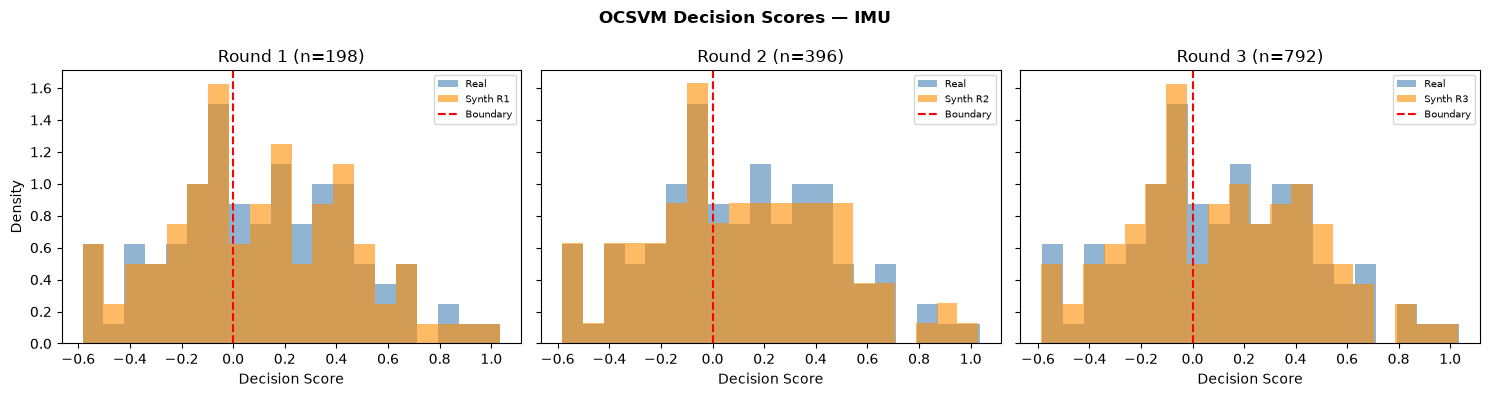

Saved: eval_ocsvm_IMU.png


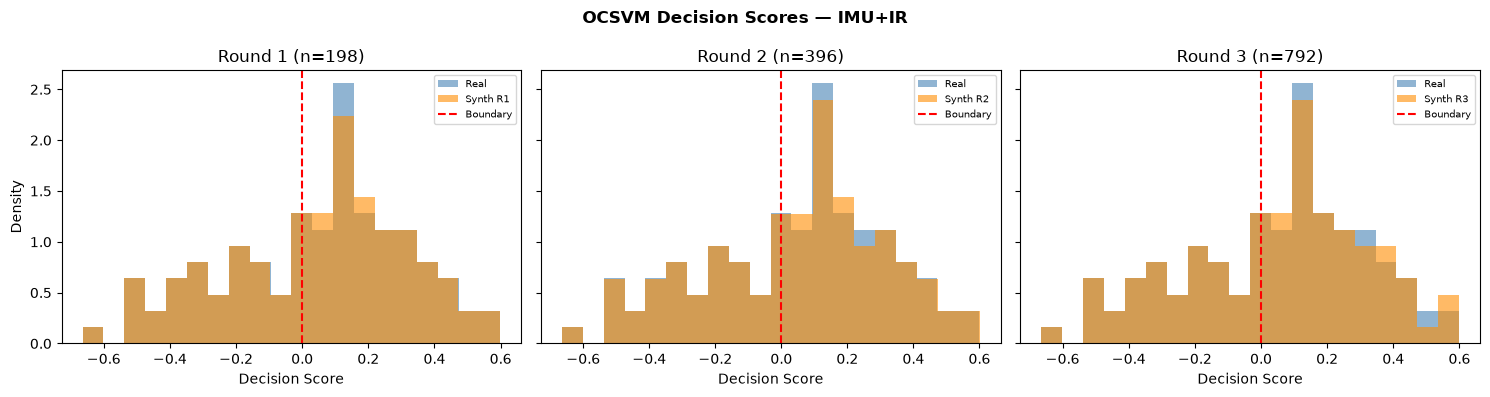

Saved: eval_ocsvm_IMU_IR.png


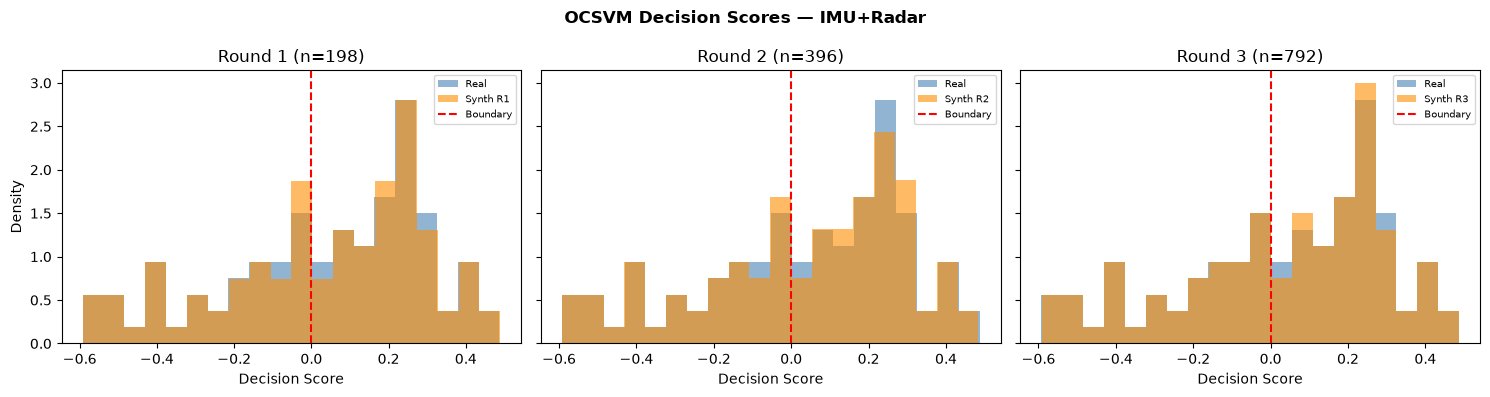

Saved: eval_ocsvm_IMU_Radar.png


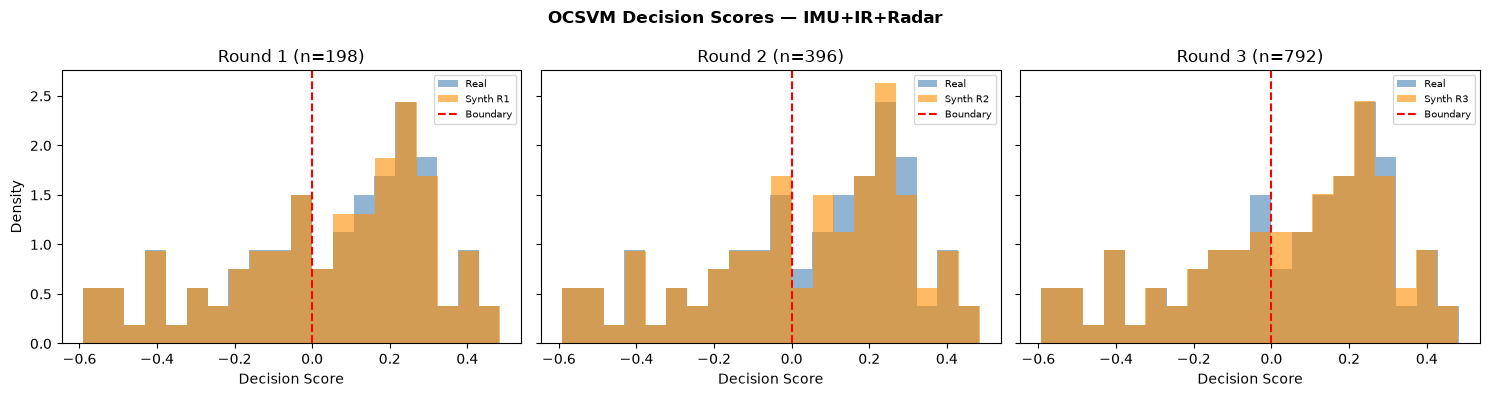

Saved: eval_ocsvm_IMU_IR_Radar.png


In [29]:
# ── OCSVM score distributions — one figure per experiment, one subplot per round

for exp_name, results in [
    ('IMU', results_imu),
    ('IMU+IR', results_imu_ir),
    ('IMU+Radar', results_imu_rd),
    ('IMU+IR+Radar', results_imu_ir_rd),
]:

    fig, axes = plt.subplots(
        1,
        N_ROUNDS,
        figsize=(5 * N_ROUNDS, 4),
        sharey=True
    )

    if N_ROUNDS == 1:
        axes = [axes]

    fig.suptitle(
        f'OCSVM Decision Scores — {exp_name}',
        fontsize=12,
        fontweight='bold'
    )


    for ax, res in zip(axes, results):

        ax.hist(
            res['_real_scores'],
            bins=20,
            alpha=0.6,
            label='Real',
            color='steelblue',
            density=True
        )

        ax.hist(
            res['_synth_scores'],
            bins=20,
            alpha=0.6,
            label=f'Synth R{res["Round"]}',
            color='darkorange',
            density=True
        )

        ax.axvline(
            0,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='Boundary'
        )

        ax.set_title(
            f'Round {res["Round"]} (n={res["Samples"]})'
        )

        ax.set_xlabel(
            'Decision Score'
        )

        ax.legend(
            fontsize=7
        )


    axes[0].set_ylabel(
        'Density'
    )


    safe_name = (
        exp_name
        .replace('+', '_')
        .replace(' ', '')
    )


    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR, f"eval_ocsvm_{safe_name}.png"),
        dpi=150,
        bbox_inches="tight"
    )
    
    plt.show()

    print(
        f"Saved: eval_ocsvm_{safe_name}.png"
    )

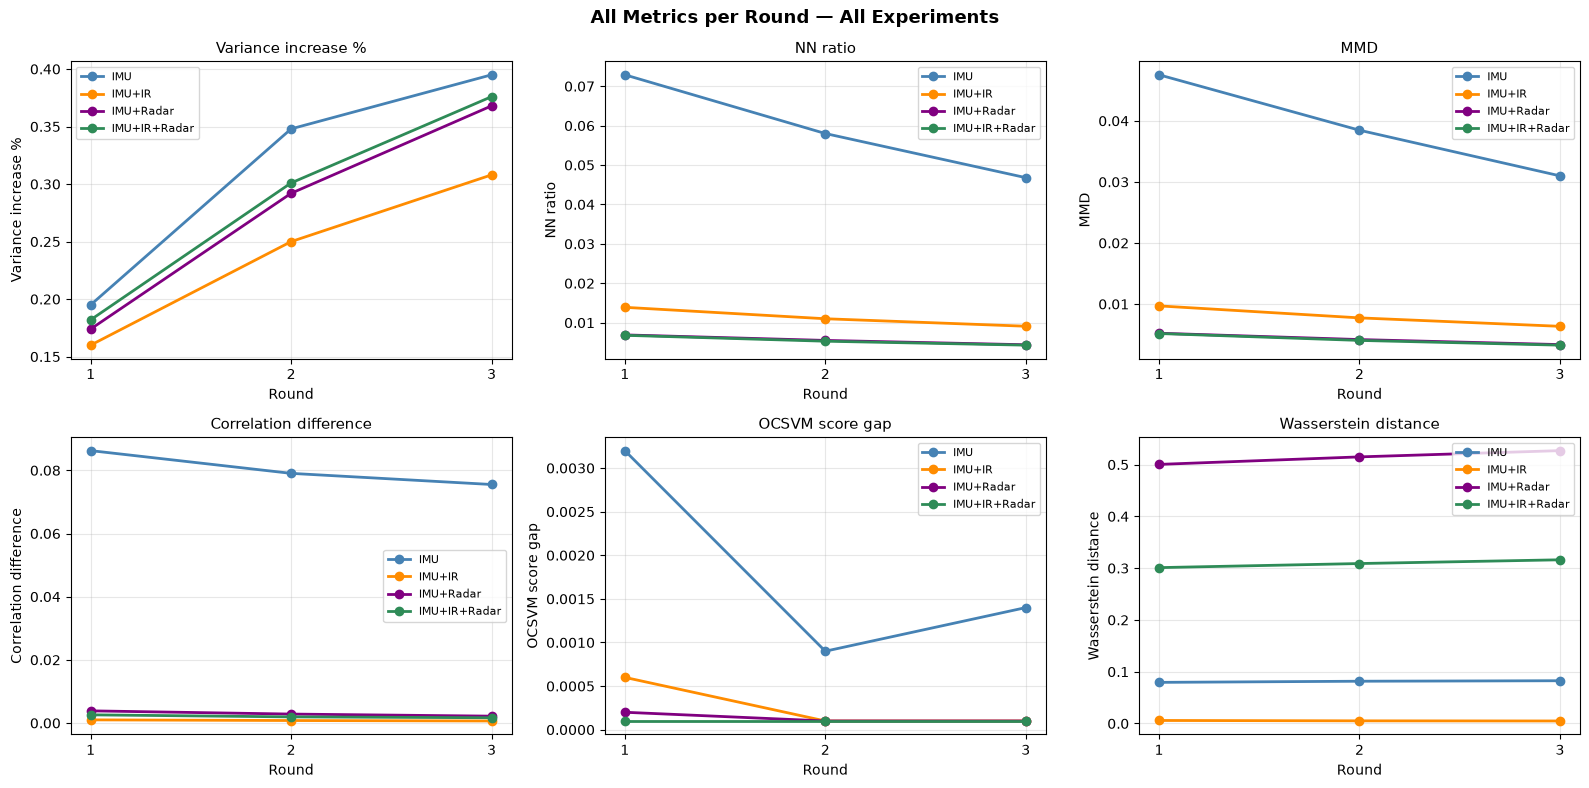

Saved: eval_metrics_per_round.png


In [31]:
# ── Multi-metric per-round line charts ────────────────────────────────────────

metrics_to_plot = [
    ('Variance_inc_%',  'Variance increase %',     False),
    ('NN_ratio',        'NN ratio',                 False),
    ('MMD',             'MMD',                      False),
    ('Corr_diff',       'Correlation difference',   False),
    ('Score_gap',       'OCSVM score gap',           False),
    ('Wasserstein',     'Wasserstein distance',      False),
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8)
)

fig.suptitle(
    'All Metrics per Round — All Experiments',
    fontsize=13,
    fontweight='bold'
)

axes = axes.flatten()


color_map = {
    'IMU': 'steelblue',
    'IMU+IR': 'darkorange',
    'IMU+Radar': 'purple',
    'IMU+IR+Radar': 'seagreen'
}


experiments = [
    ('IMU', df_imu),
    ('IMU+IR', df_imu_ir),
    ('IMU+Radar', df_imu_rd),
    ('IMU+IR+Radar', df_imu_ir_rd)
]


for ax, (col, label, _) in zip(axes, metrics_to_plot):

    for exp_name, df in experiments:

        ax.plot(
            df['Round'],
            df[col],
            marker='o',
            label=exp_name,
            color=color_map[exp_name],
            linewidth=2
        )

    ax.set_title(
        label,
        fontsize=11
    )

    ax.set_xlabel(
        'Round'
    )

    ax.set_ylabel(
        label
    )

    ax.set_xticks(
        list(range(1, N_ROUNDS + 1))
    )

    ax.legend(
        fontsize=8
    )

    ax.grid(
        True,
        alpha=0.3
    )


plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "eval_metrics_per_round.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: eval_metrics_per_round.png"
)

In [32]:
# ── PCA visualisation — Real vs Synthetic per round ──────────────────────────

def plot_pca_rounds(
    X_real,
    synth_batches,
    results,
    experiment_name,
    filename
):

    n_cols = min(N_ROUNDS, 3)
    n_rows = (N_ROUNDS + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )

    axes = np.array(axes).flatten()

    fig.suptitle(
        f'PCA Projection — {experiment_name}: Real vs Synthetic per Round',
        fontsize=13,
        fontweight='bold'
    )


    N_real = X_real.shape[0]


    # Flatten real samples
    X_real_flat = X_real.reshape(
        N_real,
        -1
    )


    # PCA fitted only on real data
    scaler = StandardScaler()

    X_real_sc = scaler.fit_transform(
        X_real_flat
    )


    pca = PCA(
        n_components=2,
        random_state=42
    )

    X_real_2d = pca.fit_transform(
        X_real_sc
    )


    for r_i, res in enumerate(results):

        ax = axes[r_i]


        X_synth = synth_batches[r_i][:N_real]


        X_synth_flat = X_synth.reshape(
            N_real,
            -1
        )


        X_synth_sc = scaler.transform(
            X_synth_flat
        )


        X_synth_2d = pca.transform(
            X_synth_sc
        )


        ax.scatter(
            X_real_2d[:,0],
            X_real_2d[:,1],
            marker='o',
            alpha=0.7,
            s=40,
            label='Real'
        )


        ax.scatter(
            X_synth_2d[:,0],
            X_synth_2d[:,1],
            marker='^',
            alpha=0.7,
            s=40,
            label=f'Synth R{r_i+1}'
        )


        ax.set_title(
            f'Round {r_i+1}\n'
            f'NN={res["NN_ratio"]:.3f} | MMD={res["MMD"]:.5f}'
        )


        ax.set_xlabel('PC 1')
        ax.set_ylabel('PC 2')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)


    for ax in axes[N_ROUNDS:]:
        ax.set_visible(False)


    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print(f"Saved: {filename}")

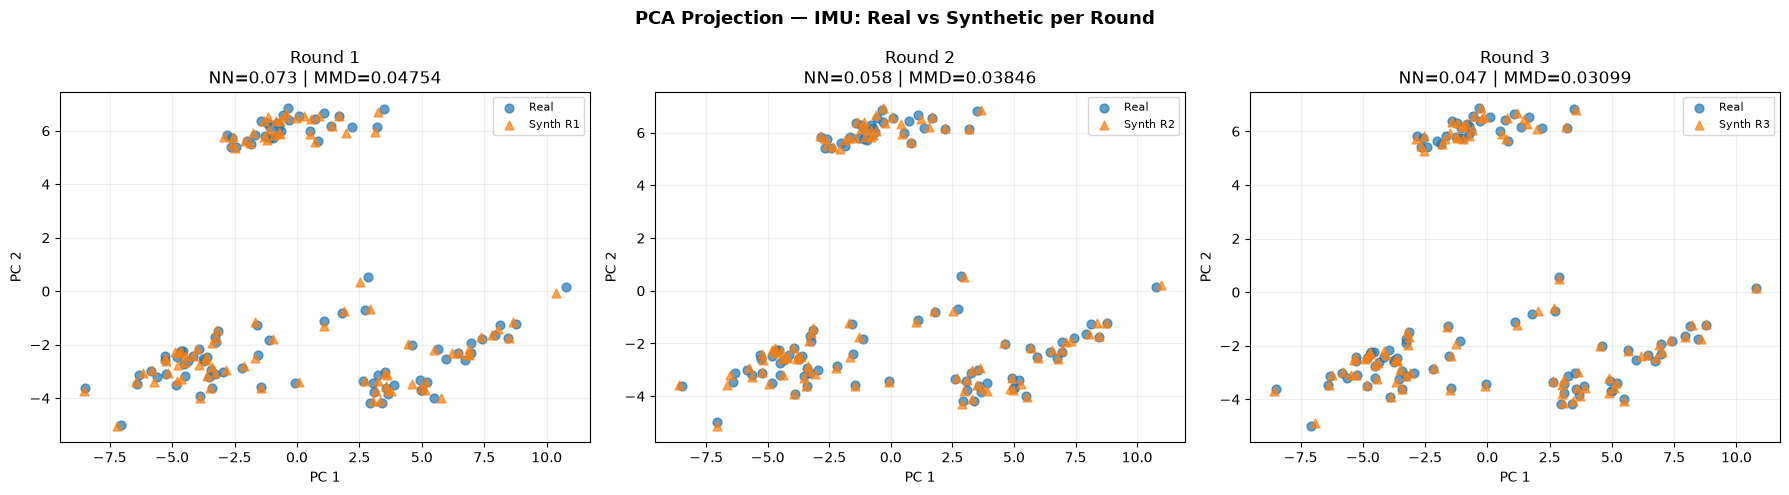

Saved: imgs\eval_pca_imu.png


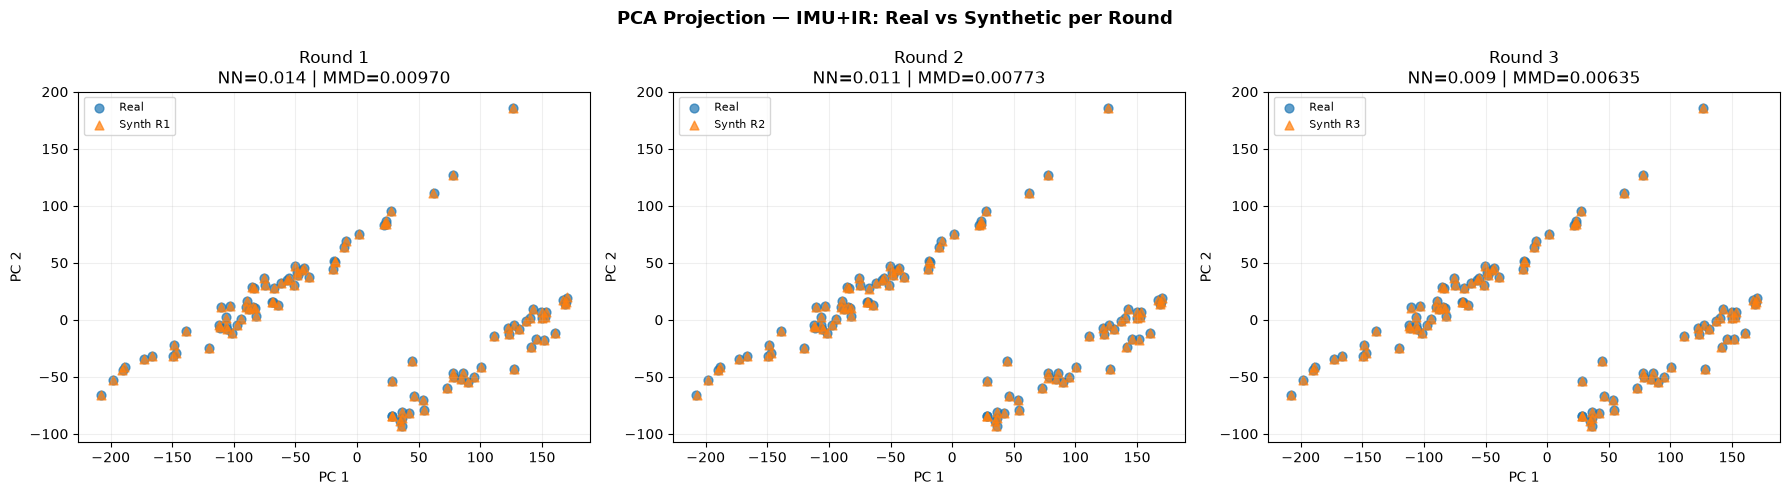

Saved: imgs\eval_pca_imu_ir.png


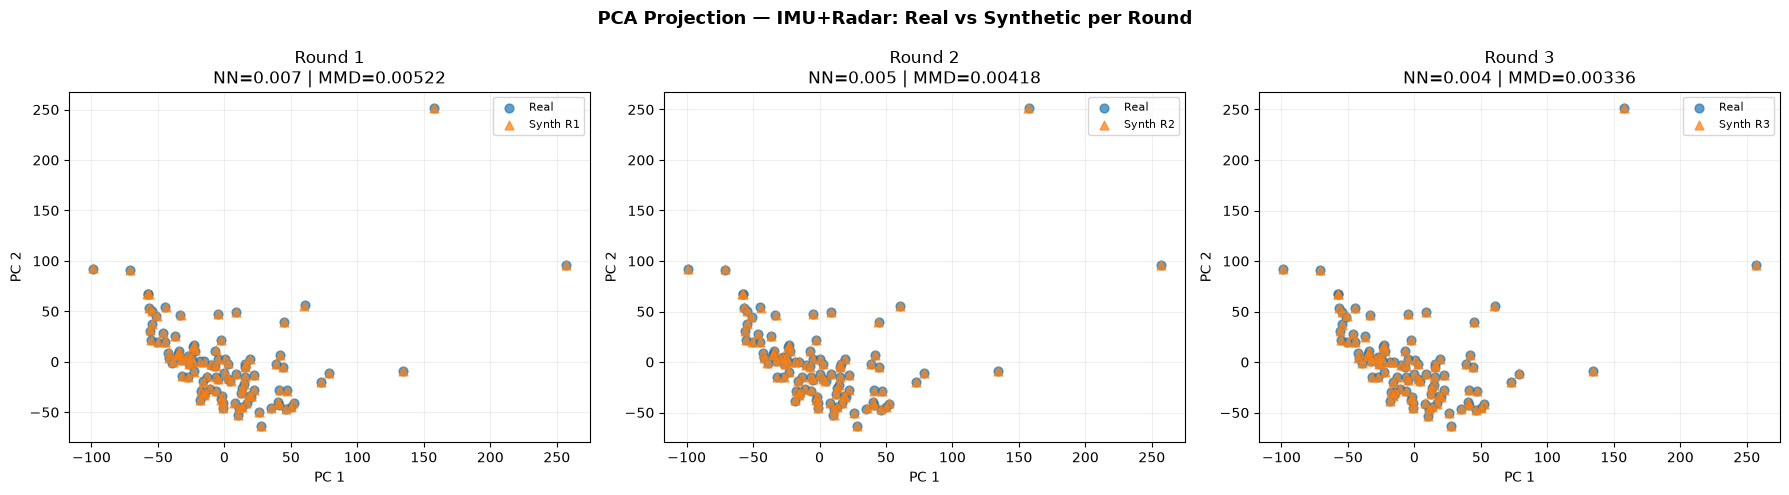

Saved: imgs\eval_pca_imu_radar.png


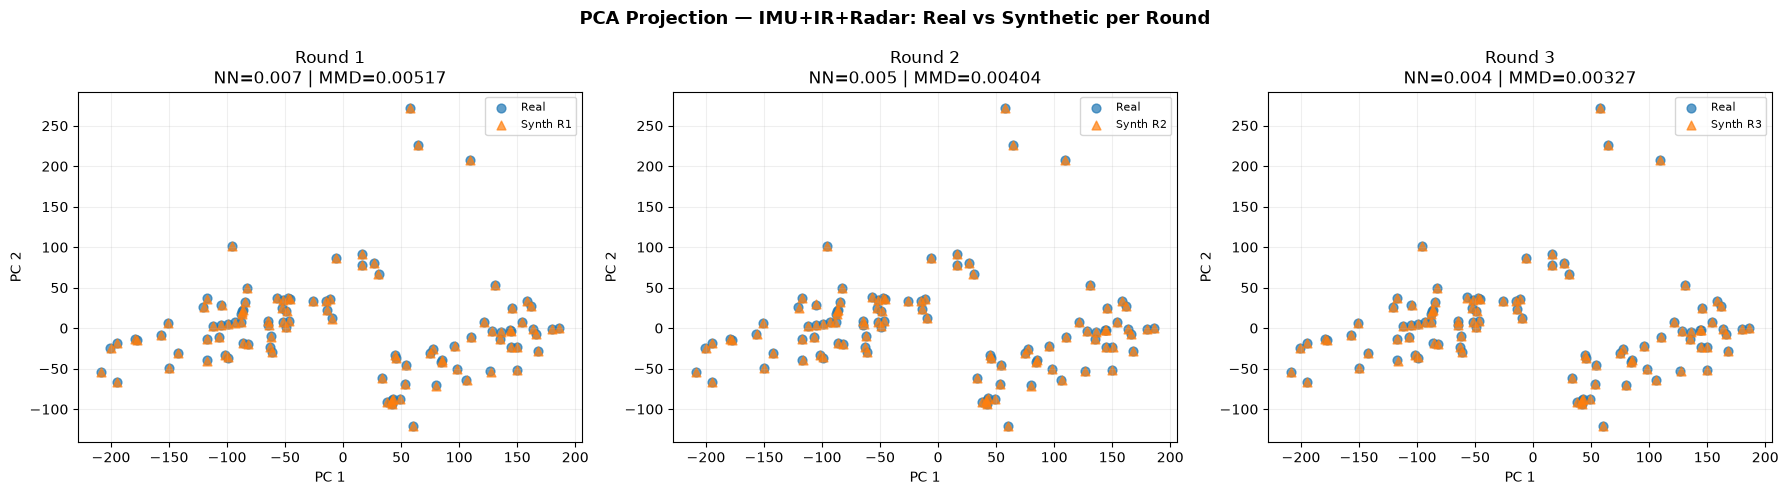

Saved: imgs\eval_pca_imu_ir_radar.png


In [34]:
plot_pca_rounds(
    X_imu,
    synth_batches_imu,
    results_imu,
    "IMU",
    os.path.join(OUTPUT_DIR, "eval_pca_imu.png")
)

plot_pca_rounds(
    X_imu_ir,
    synth_batches_imu_ir,
    results_imu_ir,
    "IMU+IR",
    os.path.join(OUTPUT_DIR, "eval_pca_imu_ir.png")
)

plot_pca_rounds(
    X_imu_rd,
    synth_batches_imu_rd,
    results_imu_rd,
    "IMU+Radar",
    os.path.join(OUTPUT_DIR, "eval_pca_imu_radar.png")
)

plot_pca_rounds(
    X_imu_ir_rd,
    synth_batches_imu_ir_rd,
    results_imu_ir_rd,
    "IMU+IR+Radar",
    os.path.join(OUTPUT_DIR, "eval_pca_imu_ir_radar.png")
)

## 13. Final Comparison Table — All Experiments × All Rounds

In [37]:
## 13. Final Comparison Table — All Experiments × All Rounds

df_all = pd.concat(
    [
        df_imu,
        df_imu_ir,
        df_imu_rd,
        df_imu_ir_rd
    ],
    ignore_index=True
)


print("\n" + "=" * 110)
print("FINAL COMPARISON TABLE — ALL EXPERIMENTS × ALL ROUNDS")
print("=" * 110)

print(df_all.to_string(index=False))


df_all.to_csv(
    os.path.join(TABLE_DIR, "eval_full_comparison.csv"),
    index=False
)

print(f"Saved: {os.path.join(TABLE_DIR, 'eval_full_comparison.csv')}")


FINAL COMPARISON TABLE — ALL EXPERIMENTS × ALL ROUNDS
  Experiment  Round  Samples  Real_boundary_%  Synth_boundary_%  Score_gap  Variance_inc_%  Wasserstein  NN_ratio      MMD  Corr_diff
         IMU      1      198             56.6              55.6     0.0032           0.195     0.079444    0.0729 0.047540   0.086251
         IMU      2      396             56.6              55.6     0.0009           0.348     0.081642    0.0580 0.038464   0.079054
         IMU      3      792             56.6              54.5     0.0014           0.395     0.082581    0.0468 0.030991   0.075526
      IMU+IR      1      198             62.6              62.6     0.0006           0.160     0.005854    0.0139 0.009698   0.000996
      IMU+IR      2      396             62.6              62.6     0.0001           0.250     0.005130    0.0110 0.007735   0.000790
      IMU+IR      3      792             62.6              61.6     0.0001           0.308     0.004867    0.0091 0.006353   0.000645
   IMU+

## 14. Automatic Round Recommendation

Identifies the optimal stopping round based on four signals:
1. Variance increase marginal gain (drops below threshold → plateau)
2. Wasserstein drift growth rate
3. NN ratio trend
4. MMD stability


In [39]:
def recommend_round(df, exp_name, var_plateau_threshold=0.05, wass_growth_threshold=1.05):
    """
    Automatic stopping-round recommendation.

    Logic:
    - Compute marginal variance gain per round (delta).
    - Compute Wasserstein growth ratio per round.
    - Compute MMD growth ratio per round.
    - Optimal round = last round where marginal variance gain >= threshold
      AND Wasserstein growth ratio < wass_growth_threshold.
    - If no round satisfies both, fall back to the round with best NN ratio.
    """
    rounds = df['Round'].values
    var    = df['Variance_inc_%'].values
    wass   = df['Wasserstein'].values
    nn     = df['NN_ratio'].values
    mmd    = df['MMD'].values

    marginal_var  = np.diff(var,  prepend=0.0)   # Δ variance each round
    wass_growth   = np.ones(len(wass))
    mmd_growth    = np.ones(len(mmd))
    wass_growth[1:] = wass[1:] / np.where(wass[:-1] > 0, wass[:-1], 1e-9)
    mmd_growth[1:]  = mmd[1:]  / np.where(mmd[:-1]  > 0, mmd[:-1],  1e-9)

    reasons = []
    optimal_r = None

    for i, r in enumerate(rounds):
        diversity_active = marginal_var[i] >= var_plateau_threshold
        drift_safe       = wass_growth[i]  <  wass_growth_threshold
        mmd_stable       = mmd_growth[i]   <= 1.10

        if diversity_active and drift_safe and mmd_stable:
            optimal_r = r

    if optimal_r is None:
        # Fallback: round with NN ratio closest to 1.0 (best fidelity)
        optimal_r = rounds[np.argmin(np.abs(nn - 1.0))]
        reasons.append("Fallback: best NN ratio (no round met all primary criteria)")
    else:
        reasons.append(f"Last round with marginal variance gain >= {var_plateau_threshold}%")
        reasons.append(f"Wasserstein growth ratio < {wass_growth_threshold}")
        reasons.append(f"MMD growth ratio <= 1.10")

    opt_row = df[df['Round'] == optimal_r].iloc[0]

    print(f"\n{'='*60}")
    print(f"  RECOMMENDATION — {exp_name}")
    print(f"{'='*60}")
    print(f"  Optimal round : {optimal_r}")
    print(f"  Total samples : {opt_row['Samples']}")
    print(f"  Variance inc  : {opt_row['Variance_inc_%']:+.3f}%")
    print(f"  Wasserstein   : {opt_row['Wasserstein']:.6f}")
    print(f"  NN ratio      : {opt_row['NN_ratio']:.4f}")
    print(f"  MMD           : {opt_row['MMD']:.6f}")
    print(f"  Corr diff     : {opt_row['Corr_diff']:.6f}")
    print(f"  Score gap     : {opt_row['Score_gap']:.4f}")
    print(f"  Reasoning:")
    for reason in reasons:
        print(f"    • {reason}")

    # Marginal gains table
    print(f"\n  Marginal variance gain per round:")
    for i, r in enumerate(rounds):
        bar = '█' * max(0, int(marginal_var[i] * 200))
        print(f"    Round {r}: Δvar={marginal_var[i]:+.3f}%  W-growth={wass_growth[i]:.3f}x  "
              f"MMD-growth={mmd_growth[i]:.3f}x  {bar}")

    return {
        'experiment':     exp_name,
        'optimal_round':  int(optimal_r),
        'total_samples':  int(opt_row['Samples']),
        'reasoning':      '; '.join(reasons),
    }


recs = []
recs.append(recommend_round(df_imu,       'IMU'))
recs.append(recommend_round(df_imu_ir,    'IMU+IR'))
recs.append(recommend_round(df_imu_rd,    'IMU+Radar'))
recs.append(recommend_round(df_imu_ir_rd, 'IMU+IR+Radar'))


  RECOMMENDATION — IMU
  Optimal round : 2
  Total samples : 396
  Variance inc  : +0.348%
  Wasserstein   : 0.081642
  NN ratio      : 0.0580
  MMD           : 0.038464
  Corr diff     : 0.079054
  Score gap     : 0.0009
  Reasoning:
    • Last round with marginal variance gain >= 0.05%
    • Wasserstein growth ratio < 1.05
    • MMD growth ratio <= 1.10

  Marginal variance gain per round:
    Round 1: Δvar=+0.195%  W-growth=1.000x  MMD-growth=1.000x  ███████████████████████████████████████
    Round 2: Δvar=+0.153%  W-growth=1.028x  MMD-growth=0.809x  ██████████████████████████████
    Round 3: Δvar=+0.047%  W-growth=1.012x  MMD-growth=0.806x  █████████

  RECOMMENDATION — IMU+IR
  Optimal round : 3
  Total samples : 792
  Variance inc  : +0.308%
  Wasserstein   : 0.004867
  NN ratio      : 0.0091
  MMD           : 0.006353
  Corr diff     : 0.000645
  Score gap     : 0.0001
  Reasoning:
    • Last round with marginal variance gain >= 0.05%
    • Wasserstein growth ratio < 1.05
   

In [41]:
rec_df = pd.DataFrame(recs)

print("\n" + "="*70)
print("RECOMMENDATION SUMMARY")
print("="*70)
print(rec_df.to_string(index=False))

rec_df.to_csv(
    os.path.join(TABLE_DIR, "eval_recommendation.csv"),
    index=False
)

print(f"\nSaved: {os.path.join(TABLE_DIR, 'eval_recommendation.csv')}")


RECOMMENDATION SUMMARY
  experiment  optimal_round  total_samples                                                                                                  reasoning
         IMU              2            396 Last round with marginal variance gain >= 0.05%; Wasserstein growth ratio < 1.05; MMD growth ratio <= 1.10
      IMU+IR              3            792 Last round with marginal variance gain >= 0.05%; Wasserstein growth ratio < 1.05; MMD growth ratio <= 1.10
   IMU+Radar              3            792 Last round with marginal variance gain >= 0.05%; Wasserstein growth ratio < 1.05; MMD growth ratio <= 1.10
IMU+IR+Radar              3            792 Last round with marginal variance gain >= 0.05%; Wasserstein growth ratio < 1.05; MMD growth ratio <= 1.10

Saved: tables\eval_recommendation.csv


## 15. OCSVM Score Summary — All Rounds

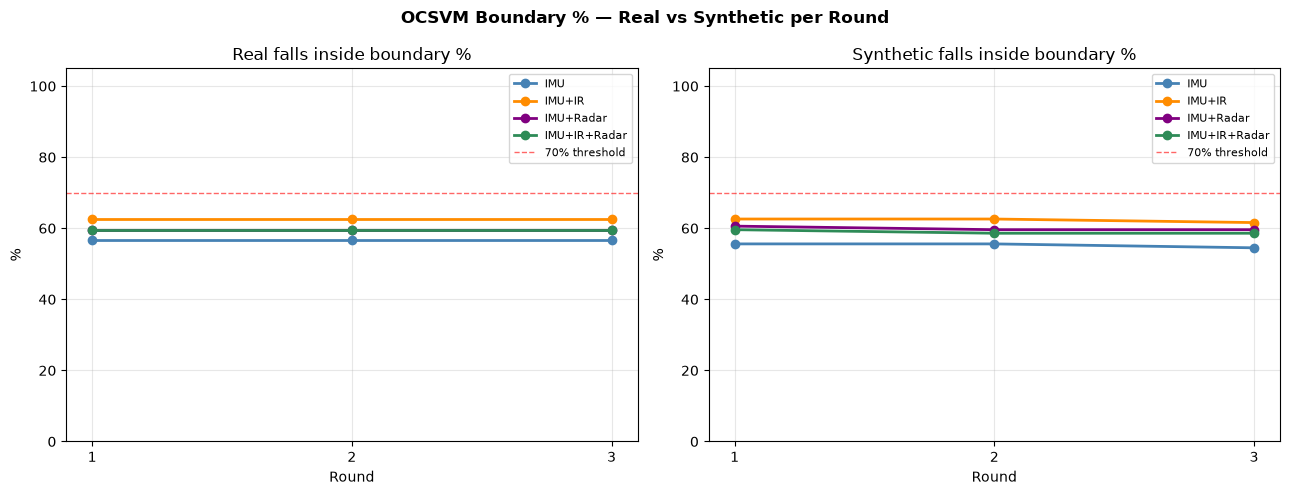

Saved: eval_ocsvm_boundary_per_round.png


In [43]:
# ── Boundary % summary across all rounds and experiments ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('OCSVM Boundary % — Real vs Synthetic per Round',
             fontsize=12, fontweight='bold')

for ax, col, title in [
    (axes[0], 'Real_boundary_%',  'Real falls inside boundary %'),
    (axes[1], 'Synth_boundary_%', 'Synthetic falls inside boundary %'),
]:
    for exp_name, df, color in [
        ('IMU',          df_imu,       'steelblue'),
        ('IMU+IR',       df_imu_ir,    'darkorange'),
        ('IMU+Radar',    df_imu_rd,    'purple'),
        ('IMU+IR+Radar', df_imu_ir_rd, 'seagreen'),
    ]:
        ax.plot(df['Round'], df[col], marker='o', label=exp_name,
                color=color, linewidth=2)
    ax.axhline(70, color='red', linestyle='--', linewidth=1, alpha=0.6, label='70% threshold')
    ax.set_title(title)
    ax.set_xlabel('Round')
    ax.set_ylabel('%')
    ax.set_ylim(0, 105)
    ax.set_xticks(list(range(1, N_ROUNDS + 1)))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "eval_ocsvm_boundary_per_round.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()
print("Saved: eval_ocsvm_boundary_per_round.png")


In [44]:
meta_real = meta.copy()

meta_real['is_augmented'] = 0
meta_real['source'] = 'real'

meta_aug = pd.concat(
    [meta_real] + meta_batches_current,
    ignore_index=True
)

print(meta_aug.head())
print(meta_aug['source'].value_counts())

   fall_id  subject_id  fall_number  is_augmented source
0        1           1            1             0   real
1        2           1            2             0   real
2        3           1            3             0   real
3        4           1            4             0   real
4        5           1            5             0   real
source
jitter_r3    396
jitter_r2    198
real          99
jitter_r1     99
Name: count, dtype: int64


## 16. Save Augmented Tensors

In [45]:
## 16. Save Augmented Tensors

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(f'{OUTPUT_DIR}/X_imu_jittered.npy',           X_imu_aug)
np.save(f'{OUTPUT_DIR}/X_imu_ir_jittered.npy',        X_imu_ir_aug)
np.save(f'{OUTPUT_DIR}/X_imu_radar_jittered.npy',     X_imu_rd_aug)
np.save(f'{OUTPUT_DIR}/X_imu_ir_radar_jittered.npy',  X_imu_ir_rd_aug)

meta_aug.to_csv(
    f'{OUTPUT_DIR}/metadata_jittered.csv',
    index=False
)

print(f"Saved to {OUTPUT_DIR}/")
print(f"  X_imu_jittered.npy           → {X_imu_aug.shape}")
print(f"  X_imu_ir_jittered.npy        → {X_imu_ir_aug.shape}")
print(f"  X_imu_radar_jittered.npy     → {X_imu_rd_aug.shape}")
print(f"  X_imu_ir_radar_jittered.npy  → {X_imu_ir_rd_aug.shape}")
print(f"  metadata_jittered.csv        → {meta_aug.shape}")

Saved to outputs/
  X_imu_jittered.npy           → (792, 32, 3)
  X_imu_ir_jittered.npy        → (792, 32, 771)
  X_imu_radar_jittered.npy     → (792, 32, 1137)
  X_imu_ir_radar_jittered.npy  → (792, 32, 1905)
  metadata_jittered.csv        → (792, 5)


## 17. Download All Outputs

In [47]:
import os

outputs = [
    # Augmented datasets
    f'{OUTPUT_DIR}/X_imu_jittered.npy',
    f'{OUTPUT_DIR}/X_imu_ir_jittered.npy',
    f'{OUTPUT_DIR}/X_imu_radar_jittered.npy',
    f'{OUTPUT_DIR}/X_imu_ir_radar_jittered.npy',
    f'{OUTPUT_DIR}/metadata_jittered.csv',
]

print("=" * 70)
print("Generated files")
print("=" * 70)

missing = []

for path in outputs:
    if os.path.exists(path):
        print(f"✓ {os.path.abspath(path)}")
    else:
        print(f"✗ Missing: {path}")
        missing.append(path)

print("\nSummary")
print(f"Files found : {len(outputs) - len(missing)}")
print(f"Files missing: {len(missing)}")

if not missing:
    print("\n✓ All outputs were generated successfully.")

Generated files
✓ c:\Users\mabideen\Downloads\Data_Augmentation\exp_1\outputs\X_imu_jittered.npy
✓ c:\Users\mabideen\Downloads\Data_Augmentation\exp_1\outputs\X_imu_ir_jittered.npy
✓ c:\Users\mabideen\Downloads\Data_Augmentation\exp_1\outputs\X_imu_radar_jittered.npy
✓ c:\Users\mabideen\Downloads\Data_Augmentation\exp_1\outputs\X_imu_ir_radar_jittered.npy
✓ c:\Users\mabideen\Downloads\Data_Augmentation\exp_1\outputs\metadata_jittered.csv

Summary
Files found : 5
Files missing: 0

✓ All outputs were generated successfully.


## 18. Metric Reference & Interpretation

| Metric | Good | Borderline | Poor |
|--------|------|------------|------|
| Synth inside boundary % | ≥ 70% | 50–70% | < 50% |
| Score gap (OCSVM) | < 0.01 | 0.01–0.05 | > 0.05 |
| Variance increase % | +5 to +20% | +1 to +5% | < +1% or > 30% |
| NN ratio | ≈ 1.0 | 1.0–1.5 | > 2.0 |
| MMD | < 0.05 | 0.05–0.15 | > 0.15 |
| Corr diff | < 0.01 | 0.01–0.05 | > 0.05 |
| Wasserstein growth ratio | < 1.05× | 1.05–1.15× | > 1.15× |

### Output files
| File | Contents |
|------|----------|
| `eval_rounds_imu.csv` | Per-round metrics, IMU experiment |
| `eval_rounds_imu_ir.csv` | Per-round metrics, IMU+IR experiment |
| `eval_rounds_imu_ir_radar.csv` | Per-round metrics, IMU+IR+Radar experiment |
| `eval_full_comparison.csv` | All experiments × all rounds combined |
| `eval_recommendation.csv` | Automatic optimal-round recommendation |
| `eval_metrics_per_round.png` | 6-panel chart of all metrics across rounds |
| `eval_pca_imu.png` | PCA projection per round (IMU experiment) |
| `eval_ocsvm_*.png` | OCSVM score histograms per round |
| `eval_ocsvm_boundary_per_round.png` | Real vs synth boundary % trend |

### Next steps
- Apply the recommended N_ROUNDS to DBA, VAE, and TimeGAN augmentation
- Unified cross-method evaluation notebook after all augmentations complete
- Normalization always inside train/test split — never before
